# Minicurso 2: Aprendizado Federado Veicular: da Teoria a Prática

Este notebook implementa o código utilizado na atividade prática do minicurso do SBRC 2026.

## Bibliotecas e módulos necessários para a execução da atividade prática do minicurso

In [1]:
%cd ..

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026


/home/gta/miniconda3/envs/afv_sbrc_2026/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [23]:
import flwr as fl
import torch

from collections import OrderedDict

from utils.data.split_data import generate_datasets
from utils.visualization.distribution import distribution_plot
from utils.utils import load_config

from architectures.torch.implementation import build_model
from architectures.torch.implementation import (
    train, 
    evaluate,
)

## Carregar os parâmetros presentes no arquivo de configurações do sistema

In [27]:
cfg = load_config("configs/config.yaml")

## 1 - Definição do ambiente federado

In [5]:
dataset_name=cfg['simulation']['data']['name']
alpha=cfg['simulation']['data']['alpha']
n_clients=cfg['simulation']['cars']

## 2 - Modelagem da heterogeneidade de clientes

### 2.1 - Heterogenidade de Dados

#### Gerando da distribuição com o valor de alfa igual a 100

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026/utils/visualization/legends.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


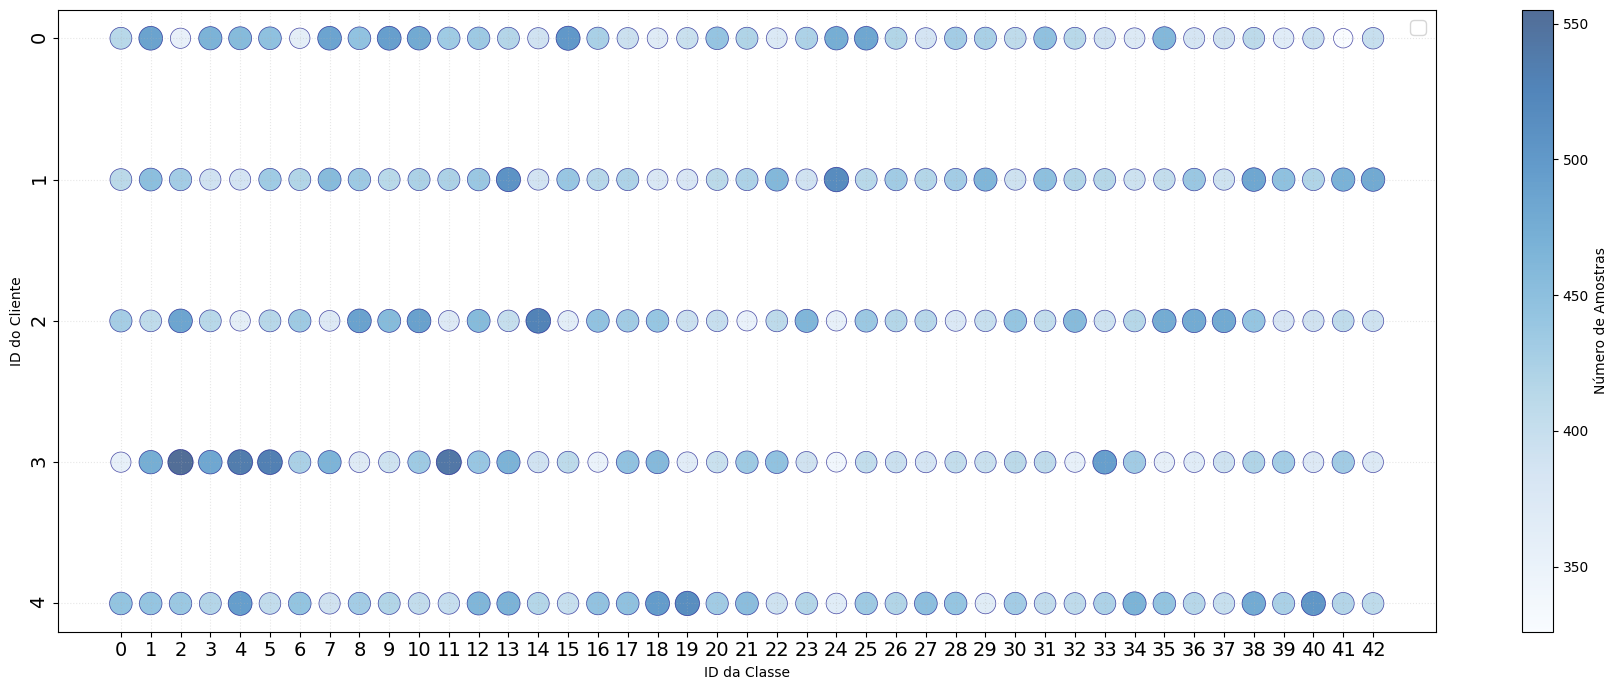

In [8]:
generate_datasets(dataset_name=dataset_name,
                  alpha=100,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 5

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026/utils/visualization/legends.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


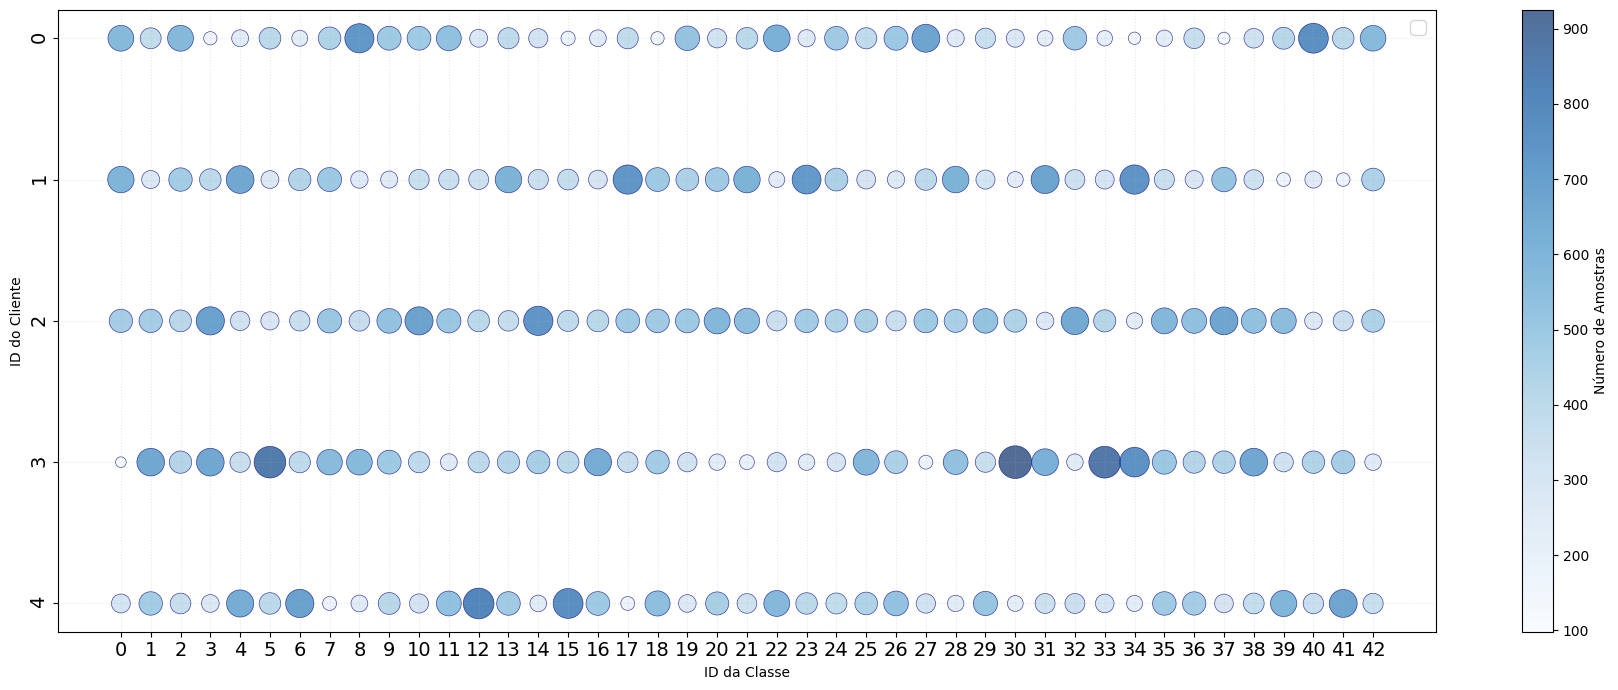

In [6]:
generate_datasets(dataset_name=dataset_name,
                  alpha=5,
                  n_clients=n_clients)

#### Gerando da distribuição com o valor de alfa igual a 0.1

/home/gta/airam/MinicursoAprendizadoFederadoVeicularSBRC2026/utils/visualization/legends.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


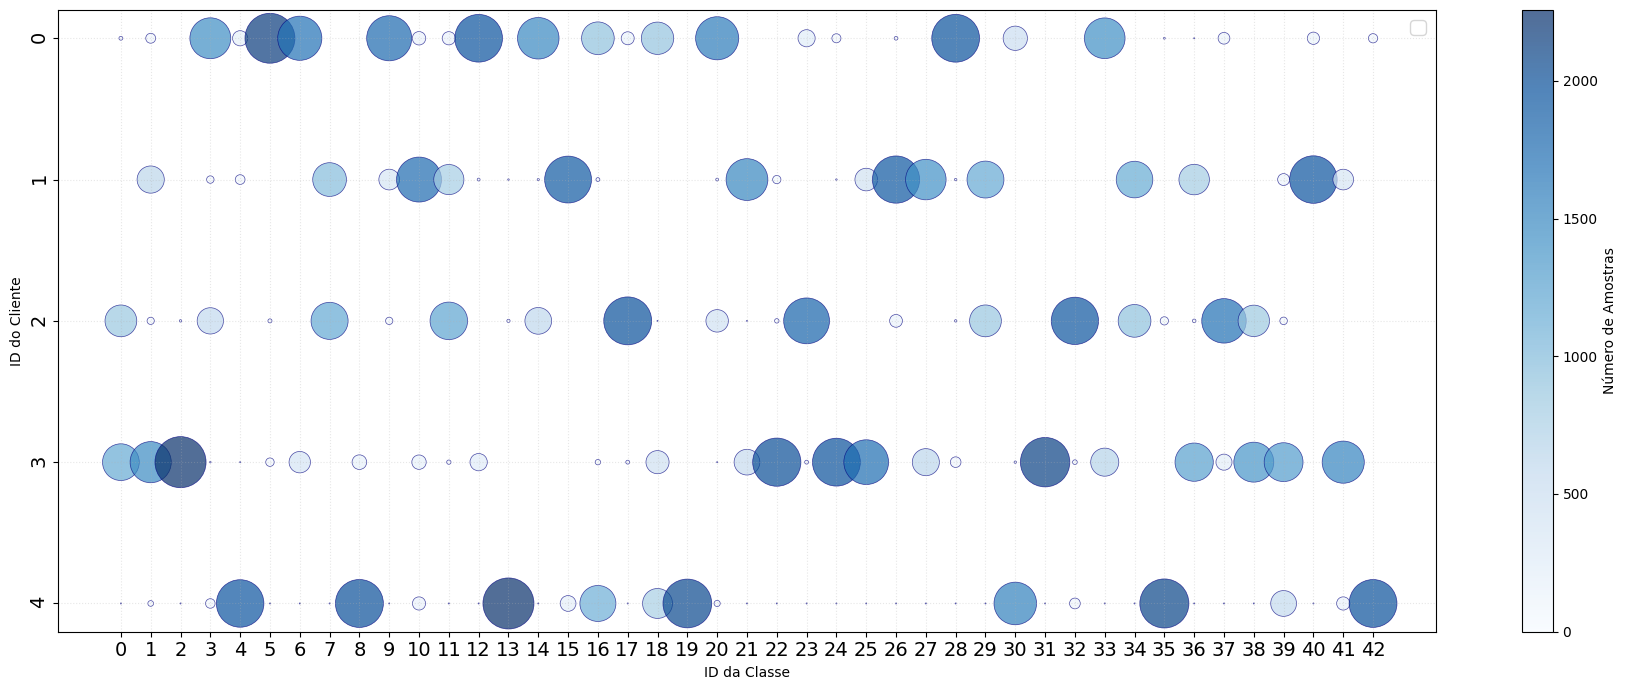

In [7]:
generate_datasets(dataset_name=dataset_name,
                  alpha=0.1,
                  n_clients=n_clients)

### 2.2 - Heterogenidade de Dispositivo 

## 3 - Simulação da mobilidade de veículos com o SUMO

### Criação dos diretórios

In [ ]:
!source scripts/build/paths.sh

### Geração do modelo de mobilidade

In [ ]:
!source scripts/run/raw/mobility.sh

### Visualização do modelo de mobilidade gerado

### Geração de dados pre-processados para o modelo de comunicação

In [ ]:
!source scripts/run/processed/mobility.sh

### Visualização dos dados de comunicação processados

## 4 - Simulação da comunicação

### Geração dos dados brutos de comunicação a partir do modelo de canal e do padrão de mobilidade fornecidos

In [9]:
!source scripts/run/raw/communication.sh

processing mobility file  2
processing mobility file  0
index  0
index  0
processing mobility file  1
index  0
processing mobility file  0
processing mobility file  1
processing mobility file  2
index  1
index  1
index  1
processing mobility file  2
index  2
processing mobility file  0
index  2
processing mobility file  1
index  2
process finished


### Processamento dos dados brutos de comunicação para utilizá-los no aprendizado federado

In [10]:
!source scripts/run/processed/communication.sh

processing file  0
processing file  1
processing file  2
processing finished
processing finished
processing finished
process finished


### Visualização dos resultados do canal de comunicação 

## 5 - Adaptação do arcabouço Flower para o treinamento federado veicular

### Preparação do Ambiente Federado Veicular

#### Criando o cliente do aprendizado federado

In [17]:
class FLClient(fl.client.NumPyClient):

    def __init__(self, 
                 *args,
                 cid=-1,
                 model=None,
                 i_epochs=5,
                 model_name="MOBILENET",
                 batch_size=32,
                 dataset="CIFAR-10",
                 strategy="fedavg",
                 model_path="",
                 result_path="",
                 computation_time_path="",
                 logger=None,
                 optimizer=None,
                 criterion=None,
                 scheduler=None,
                 device=None,
                 trainloader=None,
                 testloader=None,
                 **kwargs):
        
        # paths
        self.strategy = strategy
        self.dataset = dataset
        self.model_name = model_name
        self.model_path = model_path+model_name+'/'
        self.result_path = result_path+model_name+'/'
        self.time_path = computation_time_path+model_name+'/'
        self.logger = logger
        self.global_epoch = 0
        
        # identifiers
        self.cid = cid

        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device

        # client's data
        self.trainloader = trainloader 
        self.testloader = testloader 
        self.train_size = len(trainloader.dataset)
        self.test_size = len(testloader.dataset)

        # learning parameters
        self.i_epochs = i_epochs
        self.bs = batch_size

    def get_weights(self):
        
        result = [val.cpu().numpy() for _, val in self.model.state_dict().items()]

        return result
        
    def set_weights(self, 
                    parameters):
    
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)


    def get_properties(self, 
                       config):

        return {'cid': self.cid}

    def fit(self, 
            parameters, 
            config):
        
        self.logger.debug("updating model parameters")
        self.set_weights(parameters)

        self.logger.debug("training model")
        loss = train(self.model, 
                     self.i_epochs, 
                     self.optimizer, 
                     self.criterion,
                     self.scheduler,
                     self.device,
                     self.trainloader,
                     self.logger)

        self.logger.debug("determine client's computational time")
        # TODO: implement the loading time here

        self.logger.debug("determine client's communication time")
        # TODO: implement the loading time here
        
        self.logger.debug(f'sending parameters to server: model_weights, len(train): {self.train_size}')
        return self.get_weights(), len(self.trainloader.dataset), {'loss':loss, "cid":self.cid}

    def evaluate(self, 
                 parameters, 
                 config):
        
        self.logger.debug(f'evaluating model')  
        
        self.logger.debug("updating model parameters")
        self.set_weights(parameters)
 
        self.logger.debug("evaluating model")
        accuracy, loss = evaluate(self.model,
                                  self.device,
                                  self.criterion,
                                  self.testloader,
                                  self.logger)

        self.logger.debug(f'sending parameters to server: loss {loss}, len(test): {self.test_size} accuracy: {float(accuracy)}')
        return loss, self.test_size, {"accuracy": float(accuracy), "cid":self.cid}



#### Criando a estratégia de agregação do servidor do aprendizado federado

#### Configurando parâmetros do servidor

In [28]:
num_rounds = cfg['simulation']['federated_learning']['server']['rounds']               
server_ip = cfg['simulation']['federated_learning']['server']['ip']
server_port = cfg['simulation']['federated_learning']['server']['port']
num_clients_fit = cfg['simulation']['cars']
num_clients = cfg['simulation']['cars']
aggregation = cfg['simulation']['federated_learning']['server']['strategy']
server_log_path = cfg['simulation']['federated_learning']['server']['log_path']
server_models_path = cfg['simulation']['federated_learning']['server']['model_path']
time_path = cfg['simulation']['federated_learning']['server']['time_path']                
DATASET = cfg['simulation']['data']['name']
alpha = cfg['simulation']['data']['alpha']
MODEL = cfg['simulation']['model']['name']
n_classes = cfg['simulation']['data']['n_classes']
features_shape = int(cfg['simulation']['data']['shape'][-1])

#### Criando diretórios

In [ ]:
os.makedirs(server_log_path, 
            exist_ok=True)

#### Configurando GPU

In [21]:
message_length = 800 * 1024 * 1024

props = torch.cuda.get_device_properties(device=None)
total_memory = props.total_memory
client_memory = 1024 * 1024 * 1024 # 1 GB for the server
memory_percentage = client_memory/total_memory
torch.cuda.set_per_process_memory_fraction(memory_percentage, 
                                           device=None)

message_length = 800 * 1024 * 1024

#### Configurando estratégia de agregação

In [29]:
# Initialize model parameters
model, _, _, _, _ = build_model(features_shape=features_shape, 
                                labels_shape=n_classes,
                                model_name=MODEL,
                                lr=0.1)

ndarrays = get_weights(model)

parameters = ndarrays_to_parameters(ndarrays)

strategy = FedAvg(min_available_clients=num_clients,
                  min_fit_clients=num_clients_fit,
                  min_evaluate_clients=num_clients,
                  fraction_fit=0.01,
                  fraction_evaluate=0.01,
                  logger=logger,
                  initial_parameters=parameters,
                  time_path=time_path)        

ValueError: Model not implemented

In [ ]:
### Criando o servidor 

### Execução do treinamento federado

#### Inicializando o servidor

In [ ]:
fl.server.start_server(config=fl.server.ServerConfig(num_rounds=num_rounds),
                       server_address=server_ip+":"+server_port,
                       strategy=strategy,
                       grpc_max_message_length=message_length)

#### Inicializando os clientes

In [ ]:
import os
import numpy as np
from utils.torch.utils import get_args_client

# Get parameters
args = get_args_client()

# Set Parameters
                                                    # default parameters
client_id = args.client_id                          # 1
i_epochs = args.number_of_local_epochs              # 5
bs = args.batch_size                                # 32
ts = args.test_size                                 # 0.2
SERVER_IP = args.server_ip                          # [::]
SERVER_PORT = args.server_port                      # 8080
DATA_PATH = args.data_path                          # ../../datasets/VeReMi_Extension/mixalldata_clean.csv
DATASET_PATH = args.dataset_path                    # ../../datasets/VeReMi_Extension
DATASET = args.dataset                              # CIFAR-10         
MODEL_PATH = args.model_path                        # models/clients/flwr/
RESULT_PATH = args.result_path                      # results/clients/flwr/
LOG_PATH = args.log_path                            # logs/clients/flwr/
COMP_PATH = args.computation_time_path              # results/clients/flwr/computation_time
IMAGE_DATA = args.image_flag                        # 1
MODEL = args.model                                  # MOBILENET
num_clients = args.num_clients                      # 10
num_selected_clients = args.num_clients_fit         # 10
alpha = args.alpha                                  # 1
strategy = args.strategy                            # fedavg
scenario = args.scenario                            # all_in_one
sysd = args.sys_d                                   # 1

if scenario == "all_in_one":
    
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{client_id%2}"

import torch
import flwr as fl

from architectures.torch.implementation import build_model
from utils.torch.load_federated_data import load_data_client

from utils.loader import load_config
from .client import FLClient

from utils.torch.utils import create_logger_client

cfg = load_config('configs/config.yaml')

system_models_ids = cfg[f'system_models_ids_{sysd}']

logger = create_logger_client(LOG_PATH+MODEL+'/', 
                              client_id)

message_length = 800 * 1024 * 1024

try:
    
    props = torch.cuda.get_device_properties(device=None)
    total_memory = props.total_memory
    client_memory = 1024 * 1024 * 512 # 256 MB for each client
    memory_percentage = client_memory/total_memory
    torch.cuda.set_per_process_memory_fraction(memory_percentage, 
                                               device=None)
    
    logger.debug(f"Total memory on the system: {total_memory}.")
    logger.debug(f"Total memory percentage: {memory_percentage}.")
    logger.debug(f"Execution path: {os.getcwd()}.")
    logger.debug(f"Training with model architecture {MODEL} and dataset {DATASET}.")
    logger.debug(f"GPU: {torch.cuda.current_device()}")

except:

    pass


logger.debug("Loading dataset")
train_dataset, test_dataset = load_data_client(dataset_name=DATASET, 
                                               clientID=client_id, 
                                               numClients=num_clients, 
                                               alpha=alpha,
                                               trPer=ts,
                                               distribution="dirichlet") 

trainloader = torch.utils.data.DataLoader(train_dataset, 
                                          batch_size=bs, 
                                          shuffle=True,
                                          num_workers=0,
                                          pin_memory=True)

testloader = torch.utils.data.DataLoader(test_dataset, 
                                         batch_size=bs, 
                                         shuffle=True,
                                         num_workers=0,
                                         pin_memory=True)

logger.debug("Building model")

labels = cfg['datasets'][DATASET]['classes']
features_shape = int(cfg['datasets'][DATASET]['features'][-1])

model, criterion, optimizer, device, scheduler = build_model(features_shape=features_shape,
                                                             labels_shape=labels,
                                                             model_name=MODEL,
                                                             lr=0.1)    


logger.debug("Starting training")
logger.debug(f'cid {client_id} with mid {system_models_ids[MODEL]} model {MODEL}')
fl.client.start_client(server_address=f'{SERVER_IP}:{SERVER_PORT}', 
                       client=FLClient(cid=client_id,
                                       mid=system_models_ids[MODEL],
                                       model=model,
                                       i_epochs=i_epochs,
                                       model_name=MODEL,
                                       batch_size=bs,
                                       dataset=DATASET,
                                       strategy=strategy,
                                       model_path=MODEL_PATH,
                                       result_path=RESULT_PATH,
                                       computation_time_path=COMP_PATH,
                                       logger=logger,
                                       optimizer=optimizer,
                                       criterion=criterion,
                                       scheduler=scheduler,
                                       trainloader=trainloader,
                                       testloader=testloader,
                                       device=device).to_client(),
                                       grpc_max_message_length=message_length)

logger.debug(f"GPU: {torch.cuda.current_device()}")
